In [1]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
%run 0_load.ipynb
%run 0_config_plot_j1j2.ipynb

### Energy 

fig/it_500_l_8/EGS_L_8_IT_500_W_45_J_10_FFNN.png


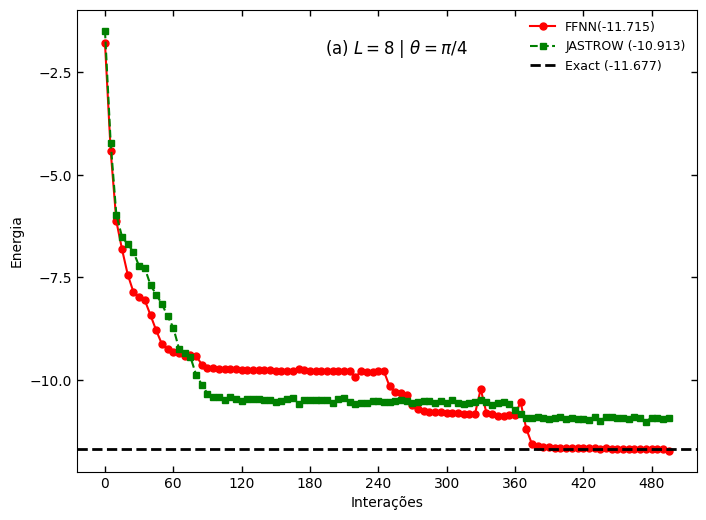

In [2]:
L = 8; ex_0 = '00'; ex_n = '10'; ll = '8'; wT = '45'; it = 500; path = fr"data/server/it_{it}_l_{ll}"
l_info = ['FFNN'];str_nets = l_info[0]
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_0, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)

path_img = fr"fig/it_{it}_l_{ll}/"
plot(ll,it,str_nets,wT,l_info,ex_n,
     exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 
     1,path_img)

L = 8; W = 0

fig/it_100_l_8/EGS_L_8_IT_100_W_0_J_77_FFNN.png


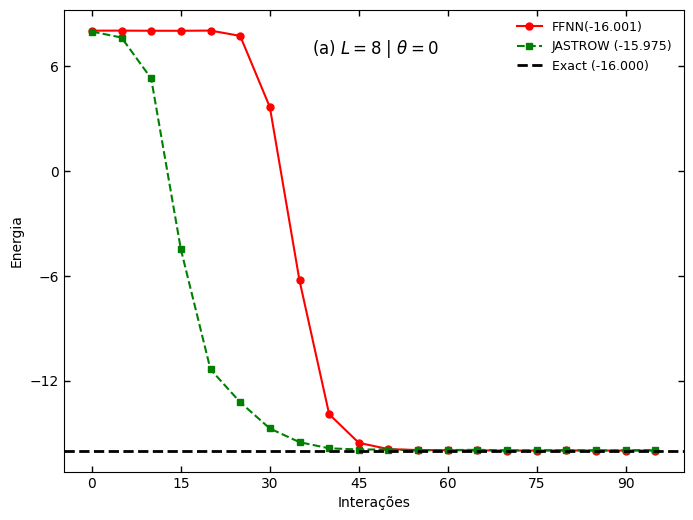

In [3]:
ex_0 = '00'; ex_n = '77'; ll = '8'; wT = '0'; it = 100; path = fr"data/server/it_{it}_l_{ll}/"
l_info = ['FFNN'];str_nets = l_info[0]
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_0, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)

path_img = fr"fig/it_{it}_l_{ll}/"
plot(ll,it,str_nets,wT,l_info,ex_n,
     exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 
     1,path_img)

In [4]:
def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff.dot(inv_cov).dot(diff.T))

def remove_outliers_m(df, k):
    X = df[['F_Egs']]

    mean_vec = X.mean().values
    cov_mat = np.cov(X.values, rowvar=False)
    inv_cov_mat = np.linalg.inv(np.atleast_2d(cov_mat))

    # Calcula a distância para cada valor
    X['mahal'] = X.apply(lambda row: mahalanobis_distance(row.values, mean_vec, inv_cov_mat), axis=1)

    # Percentil de corte — queremos manter 90% (remover 10%)
    quantil_corte = k

    # Encontra o valor de distância correspondente ao 90º percentil
    threshold = X['mahal'].quantile(quantil_corte)

    # Remove outliers
    df_sem_outliers = df[X['mahal'] <= threshold]    
    return df_sem_outliers    

In [5]:
def remove_outliers(df):
    Q1 = df['F_Egs'].quantile(0.25)
    Q3 = df['F_Egs'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar dados sem outliers
    df_sem_outliers = df[(df['F_Egs'] >= limite_inferior) & (df['F_Egs'] <= limite_superior)]
    return df_sem_outliers      

In [6]:
def plot_q(L,T,IT,wT,str_nets,df,show,path_img):
    plt.figure(figsize=(6, 4))
    df['F_Egs'].plot(kind='box', vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))

    plt.title('Distribuição de F_Egs (Boxplot)')
    plt.ylabel('Valores')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    create(path_img)
    path_img = path_img +  f"EGS_BOX_PLOT_{T}_L_{L}_IT_{IT}_W_{wT}_{str_nets}.png"
    plt.savefig(path_img, dpi=300, bbox_inches='tight')
    if show == 1:
        plt.show()
    plt.close()  

### JOBS

In [7]:
def run_job(ex_0, wT, ll, it, j_lim,th,show, path):
    try:
        exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
        
        df,m_val,m_id   = jobs_egs(ll,wT,it,path,j_lim)
        plot_jobs(int(ll),it,str_nets,wT,exact_gs_energy,
                  df,1,show,path_img)
        plot_q(ll,1,it,wT,str_nets,df,show,path_img)

        
        df_ = remove_outliers(df)
        plot_jobs(int(ll),it,str_nets,wT,exact_gs_energy,
                  df_,2,show,path_img)
        plot_q(ll,2,it,wT,str_nets,df_,show,path_img)
       

        df__ = remove_outliers_m(df_,th)
        plot_jobs(int(ll),it,str_nets,wT,exact_gs_energy,
                  df__,3,show,path_img)
        plot_q(ll,3,it,wT,str_nets,df__,show,path_img)
       
        
    except:
        print(fr"{wT} Não Definido")

In [8]:
%run 0_config_plot_j1j2.ipynb

In [13]:
ws = [210]; th = 0.90
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 100
    path = fr"data/server/it_{it}_l_{ll}/"
    run_job(ex_0, wT, ll, it, j_lim, th, 0, path)

In [ ]:
ws = [60]; th = 0.90
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, th, 0, path)

In [ ]:
ws = [150]; th = 0.90
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, th, 1, path)

In [ ]:
ws = [150]; th = 0.90
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, th, 1, path)

In [ ]:
ws = [225,245,300]; th = 0.90
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, th, 1, path)

In [ ]:
ex_0 = '00'; ll = '8'; wT = '0'; it = 100; j_lim = 100
run_job(ex_0, wT, ll, it, j_lim, path)

In [ ]:
ws = [0,15,20,22,23,24,25]

In [ ]:
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 100; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, path)

In [ ]:
path

In [ ]:
wT = '0'; it = 200; j_lim = 100; path = fr"data/server/it_{it}_l_{ll}/"

In [ ]:
path

In [ ]:
ws = [30,45,60,210,225]
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 200; j_lim = 100
    run_job(ex_0, wT, ll, it, j_lim, path)

In [ ]:
%run 0_load.ipynb

In [ ]:
wT = '30'; it = 500; j_lim = 2; path = fr"data/server/it_{it}_l_{ll}"

In [ ]:
path

In [ ]:
ws = [30,45]
for w in ws:
    ex_0 = '00'; ll = '8'; wT = str(w); it = 500; j_lim = 2
    run_job(ex_0, wT, ll, it, j_lim, path)

#### PREPARE DATA

In [ ]:
%run 0_load.ipynb

In [ ]:
ex_0 = '00'; ex_n = '77'; ll = '8'; wT = '0'; it = 100; j_lim = 100
path = fr"data/server/it_{it}_l_{ll}/"
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
df,m_val,m_id   = jobs_egs(ll,wT,it,path,j_lim)

In [ ]:
m_val,m_id,exact_gs_energy

In [ ]:
wT

### PLOT

In [ ]:
%run 0_config_plot_j1j2.ipynb

In [ ]:
wT = 0

In [ ]:
path, ll,wT

In [ ]:
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)

In [ ]:
exact_gs_energy

In [ ]:
plot(ll,it,str_nets,wT,l_info,ex_n,
     exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 
     1,path_img)

In [ ]:
path_img = fr"fig/it_{it}_l_{ll}/"

In [ ]:
wT

In [ ]:
plot_jobs(int(ll), it,str_nets,wT,exact_gs_energy,
              df,1,path_img)

In [ ]:
ex_n = '00'; ll = '8'; wT = '15'; it = 100; path = 'data/server/it_100_l_8' 
exact_gs_energy = f_exact_gs_energy(path,ex_n,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_n, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)
plot(L,IT,str_nets,wT,l_info,exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 1)

In [ ]:
ex_n = '00'; ll = '14'; wT = '15'; it = 400; path = 'data/server/it_400_l_14_ex3' 
exact_gs_energy = f_exact_gs_energy(path,ex_n,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_n, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)
plot(L,IT,str_nets,wT,l_info,exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 1)

In [ ]:
ex_0 = '00'; ex_n = '01'; ll = '14'; wT = '15'; it = 400; path = 'data/server/it_400_l_14_ex3' 
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_0, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)
plot(L,IT,str_nets,wT,l_info,exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 1)

In [ ]:
ex_0 = '00'; ex_n = '01'; ll = '18'; wT = '30'; it = 400; path = 'data/server/it_400_l_18_ex4'
l_info = ['FFNN'];str_nets = l_info[0]
exact_gs_energy = f_exact_gs_energy(path,ex_0,ll,wT)
iters_Jastrow_ds, energy_Jastrow_ds = f_jastrow(path,ex_0, ll, wT, it)
iters_Net_ds    , energy_Net_ds     = f_ffnn(path,ex_n, ll, wT, it)
plot(ll,it,str_nets,wT,l_info,exact_gs_energy,iters_Jastrow_ds,energy_Jastrow_ds,iters_Net_ds,energy_Net_ds, 1)

In [ ]:
x1 = df["id"]
egs = df["F_Egs"]
median_val  = egs.median()
closest_idx = (egs - median_val).abs().idxmin()
id_median   = df.loc[closest_idx, "id"]
egs_median  = df.loc[closest_idx, "F_Egs"]

print(f"Mediana ≈ {median_val:.6f}")
print(f"ID mais próximo da mediana: {id_median} (valor = {egs_median:.6f})")


In [ ]:
df.head()

### Jobs

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
x_pos = 0.4
y_pos = 0.94
i = 0

x1 = df["id"]
egs = df["F_Egs"]

median_val = egs.median()
median_id  = df.query('F_Egs' == median_val)['id']

ax.plot(
    x1, egs,
    label=r"$E_{gs}$",
    linestyle=linestyles[i],
    marker=markers[i],
    color=colors[i],
    markersize=5,
    alpha=0.7
)

ax.axhline(
    y=median_val,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=fr"Mediana = {median_val:.4f}"
)

ax.set_ylabel(r"Energy", fontsize=12)
ax.set_xlabel(r"Jobs", fontsize=12)

ax.tick_params(direction='in', length=4, width=1.0, top=True, 
               bottom=True, left=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, 
               width=0.8, top=True, bottom=True, left=True, right=True)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_minor_locator(FixedLocator([]))


w    = int(wT);  
f_wt = ftheta(w)
ax.text(x_pos, y_pos, f'(a) $L={ll}$ | {f_wt}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top')

ax.legend(
    fontsize=9, loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True, framealpha=1,
    edgecolor='black'
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # espaço para legenda
plt.show()
plt.close()


In [ ]:
df = pd.DataFrame({
    'id': range(1, len(F_Egs) + 1),   # sequência 1, 2, 3, ...
    'F_Egs': F_Egs                    # valores da lista
})

In [ ]:
df.head()

In [ ]:
len(F_Egs)

In [ ]:
F_Egs = []
ex_0 = '00'; ll = '18'; wT = 30; it = 400; path = 'data/server/it_400_l_18_ex4' 
for i in range (0,101):
    ex_n = digts(i)
    try:
        iters_Net_ds,energy_Net_ds = f_ffnn(path,ex_n, ll, wT, it)  
        F_Egs.append(energy_Net_ds[-1])
    except:
        print(i)

In [ ]:
F_Egs

In [ ]:
(exact_gs_energy,energy_Jastrow_ds[-1],energy_Net_ds[-1])

In [ ]:
for i in range(0,10):
    ex_n = digts(i)
    break;